# Connectivity Density Modelling

Model functional connectivity density from structural connectivity density for each brain region and assess associations with multiple-comparison correction.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## Connectivity Density Modelling

For each vertex i, structural and functional densities were computed as the sum of rows (ignoring the diagonal). Functional connectivity density was modelled based on structural connectivity density for each vertex across 19 subjects. Significance was assessed using the Bonferroni correction ($p<0.00074$) to control the family-wise error rate.

In [1]:
from pathlib import Path
figure_dir = Path("figures/connectivity_density_modelling")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import glob
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

base_path = "data/connectomes/"

def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break
    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]
    df = pd.read_csv(path, header=None, comment="#")
    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names
    return df

structural, functional = {}, {}
for pid in range(32, 51):
    s_path = f"{base_path}{pid}_WFA_68.csv"
    f_path = f"{base_path}{pid}_rsfMRI_68.csv"
    structural[pid] = load_connectome(s_path)
    functional[pid] = load_connectome(f_path)

subjects  = sorted(structural.keys())
regions   = structural[subjects[0]].index.tolist()
n_regions = len(regions)

print(f"Loaded {len(subjects)} subjects, {n_regions} regions.")
print("Example regions:", regions[:4])

Loaded 19 subjects, 68 regions.
Example regions: ['banks_superior_temporal_sulcus_left', 'caudal_anterior_cingulate_cortex_left', 'caudal_middle_frontal_gyrus_left', 'cuneus_left']


In [2]:
# shape: (n_subjects, n_regions)
struct_density = np.zeros((len(subjects), n_regions))
func_density   = np.zeros((len(subjects), n_regions))

for s_idx, pid in enumerate(subjects):
    S = structural[pid].values.copy()
    F = functional[pid].values.copy()
    np.fill_diagonal(S, 0)
    np.fill_diagonal(F, 0)
    struct_density[s_idx] = S.sum(axis=1)
    func_density[s_idx]   = F.sum(axis=1)

# Wrap in DataFrames for convenience (rows=subjects, cols=regions)
struct_df = pd.DataFrame(struct_density, index=subjects, columns=regions)
func_df   = pd.DataFrame(func_density,   index=subjects, columns=regions)

print("Structural density (first 3 subjects, 4 regions):")
print(struct_df.iloc[:3, :4].round(3))
print("\nFunctional density (first 3 subjects, 4 regions):")
print(func_df.iloc[:3, :4].round(3))

Structural density (first 3 subjects, 4 regions):
    banks_superior_temporal_sulcus_left  \
32                                5.984   
33                                6.325   
34                               12.253   

    caudal_anterior_cingulate_cortex_left  caudal_middle_frontal_gyrus_left  \
32                                 11.604                            15.187   
33                                 12.866                            19.787   
34                                 10.613                            15.233   

    cuneus_left  
32        4.259  
33        2.479  
34        6.526  

Functional density (first 3 subjects, 4 regions):
    banks_superior_temporal_sulcus_left  \
32                               -0.577   
33                               -0.519   
34                               -0.289   

    caudal_anterior_cingulate_cortex_left  caudal_middle_frontal_gyrus_left  \
32                                 -0.730                            -0.869   
33    

In [3]:
results = []

for i, region in enumerate(regions):
    x = struct_density[:, i]   # structural density across subjects
    y = func_density[:, i]     # functional density across subjects

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    r2   = model.rsquared
    beta = model.params[1]
    pval = model.pvalues[1]
    alpha = model.params[0]

    results.append({
        "region": region,
        "alpha": alpha,
        "beta":  beta,
        "r2":    r2,
        "pval":  pval,
    })

results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)

# Bonferroni-corrected significance threshold
bonferroni = 0.05 / n_regions
results_df["significant"] = results_df["pval"] < bonferroni

print(f"Bonferroni threshold: p < {bonferroni:.4f}")
print(f"Significant vertices: {results_df['significant'].sum()} / {n_regions}\n")
print("Top 10 vertices by R²:")
print(results_df[["region","beta","r2","pval","significant"]].head(10).to_string(index=False))

Bonferroni threshold: p < 0.0007
Significant vertices: 0 / 68

Top 10 vertices by R²:
                                       region      beta       r2     pval  significant
                  superior_frontal_gyrus_left -0.060840 0.290726 0.017204        False
inferior_frontal_gyrus_pars_triangularis_left  0.086501 0.257377 0.026612        False
                superior_parietal_gyrus_right -0.049277 0.219940 0.042813        False
                   parahippocampal_gyrus_left -0.056952 0.208213 0.049564        False
           rostral_middle_frontal_gyrus_right -0.042931 0.196871 0.057051        False
                   middle_temporal_gyrus_left  0.056189 0.187059 0.064394        False
                  middle_temporal_gyrus_right  0.062397 0.167116 0.082244        False
                            frontal_pole_left  0.129669 0.156578 0.093547        False
                 superior_parietal_gyrus_left -0.039012 0.153926 0.096626        False
                 inferior_parietal_gyrus_lef

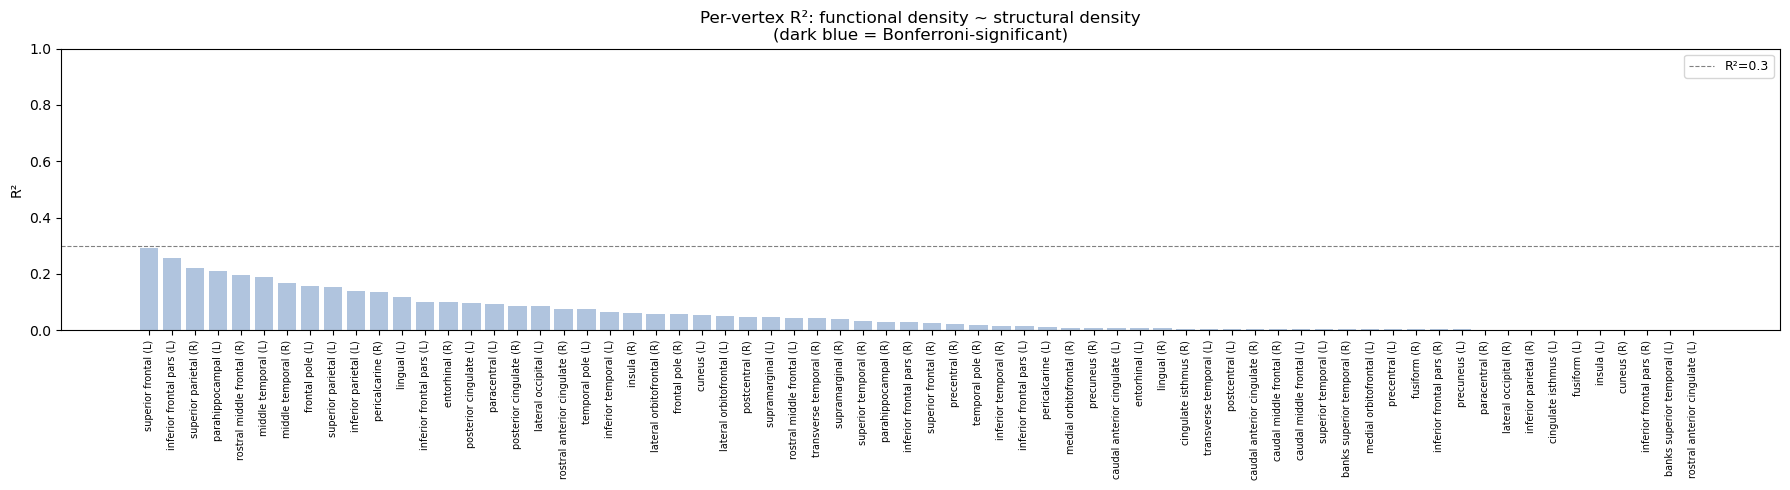

In [4]:
def short_label(name):
    hemi = "(L)" if name.endswith("_left") else ("(R)" if name.endswith("_right") else "")
    stem = name.replace("_left", "").replace("_right", "")
    parts = [p for p in stem.split("_") if p not in {"gyrus", "cortex", "sulcus"}]
    return " ".join(parts[:3]) + (" " + hemi if hemi else "")

labels = [short_label(r) for r in results_df["region"]]
colors = ["steelblue" if sig else "lightsteelblue" for sig in results_df["significant"]]

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(range(n_regions), results_df["r2"], color=colors, edgecolor="none")
ax.set_xticks(range(n_regions))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel("R²")
ax.set_title("Per-vertex R²: functional density ~ structural density\n(dark blue = Bonferroni-significant)")
ax.set_ylim(0, 1)
ax.axhline(0.3, color="gray", linestyle="--", linewidth=0.8, label="R²=0.3")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(figure_dir / 'r2_barplot.png'), dpi=180, bbox_inches="tight")
plt.show()

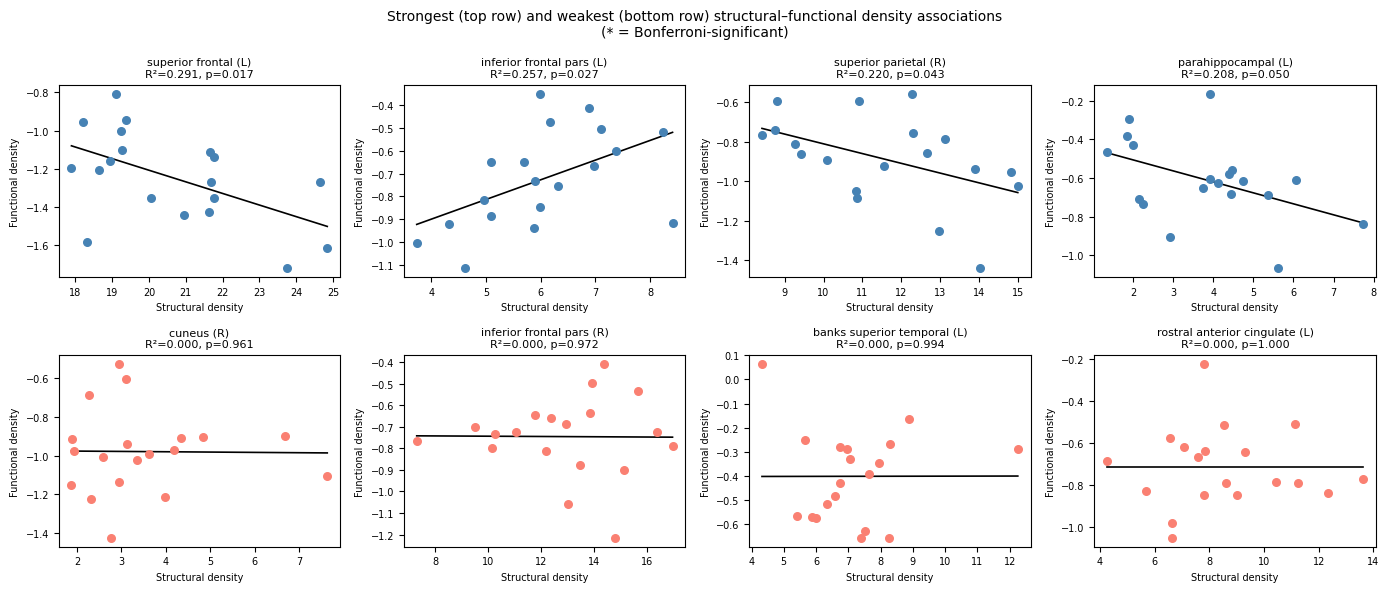

In [5]:
def plot_vertex_scatter(ax, region, row, color):
    i = regions.index(region)
    x = struct_density[:, i]
    y = func_density[:, i]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = row["alpha"] + row["beta"] * x_line

    ax.scatter(x, y, color=color, s=30, zorder=3)
    ax.plot(x_line, y_line, color="black", linewidth=1.2)
    sig_marker = "*" if row["significant"] else ""
    ax.set_title(f"{short_label(region)}{sig_marker}\nR²={row['r2']:.3f}, p={row['pval']:.3f}",
                 fontsize=8)
    ax.set_xlabel("Structural density", fontsize=7)
    ax.set_ylabel("Functional density", fontsize=7)
    ax.tick_params(labelsize=7)

top4    = results_df.head(4)
bottom4 = results_df.tail(4)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Strongest (top row) and weakest (bottom row) structural–functional density associations\n(* = Bonferroni-significant)",
             fontsize=10)

for ax, (_, row) in zip(axes[0], top4.iterrows()):
    plot_vertex_scatter(ax, row["region"], row, "steelblue")

for ax, (_, row) in zip(axes[1], bottom4.iterrows()):
    plot_vertex_scatter(ax, row["region"], row, "salmon")

plt.tight_layout()
plt.savefig(str(figure_dir / 'scatter_top_bottom.png'), dpi=180, bbox_inches="tight")
plt.show()

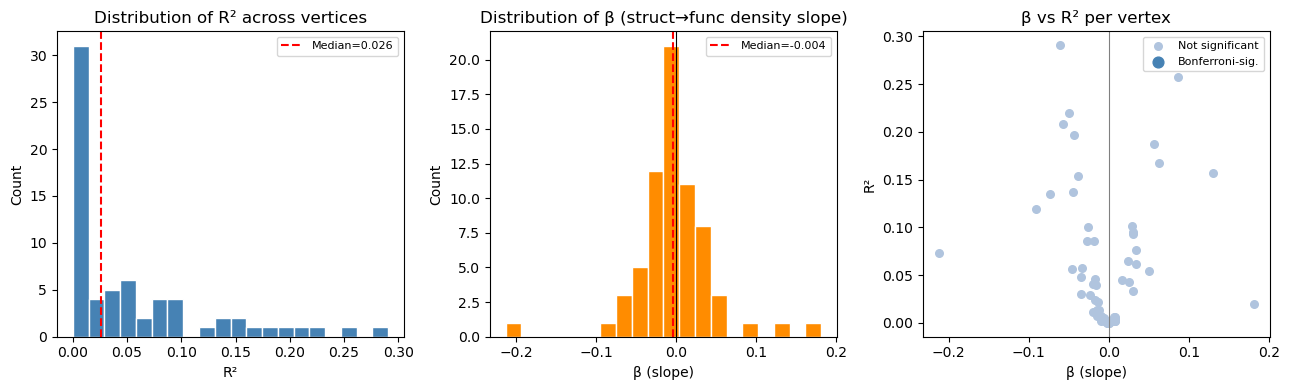


Summary statistics:
            r2     beta     pval
count  68.0000  68.0000  68.0000
mean    0.0555  -0.0037   0.5193
std     0.0704   0.0486   0.3154
min     0.0000  -0.2128   0.0172
25%     0.0028  -0.0197   0.2232
50%     0.0264  -0.0042   0.5072
75%     0.0859   0.0076   0.8313
max     0.2907   0.1816   0.9999


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# R² histogram
axes[0].hist(results_df["r2"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(results_df["r2"].median(), color="red", linestyle="--", label=f"Median={results_df['r2'].median():.3f}")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of R² across vertices")
axes[0].legend(fontsize=8)

# β histogram
axes[1].hist(results_df["beta"], bins=20, color="darkorange", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline(results_df["beta"].median(), color="red", linestyle="--", label=f"Median={results_df['beta'].median():.3f}")
axes[1].set_xlabel("β (slope)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of β (struct→func density slope)")
axes[1].legend(fontsize=8)

# β vs R² scatter — colour-coded by significance
sig_mask = results_df["significant"]
axes[2].scatter(results_df.loc[~sig_mask, "beta"], results_df.loc[~sig_mask, "r2"],
                color="lightsteelblue", s=30, label="Not significant", zorder=2)
axes[2].scatter(results_df.loc[sig_mask, "beta"], results_df.loc[sig_mask, "r2"],
                color="steelblue", s=60, label="Bonferroni-sig.", zorder=3)
axes[2].axvline(0, color="gray", linewidth=0.8)
axes[2].set_xlabel("β (slope)")
axes[2].set_ylabel("R²")
axes[2].set_title("β vs R² per vertex")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(figure_dir / 'distributions.png'), dpi=180, bbox_inches="tight")
plt.show()

print("\nSummary statistics:")
print(results_df[["r2", "beta", "pval"]].describe().round(4))

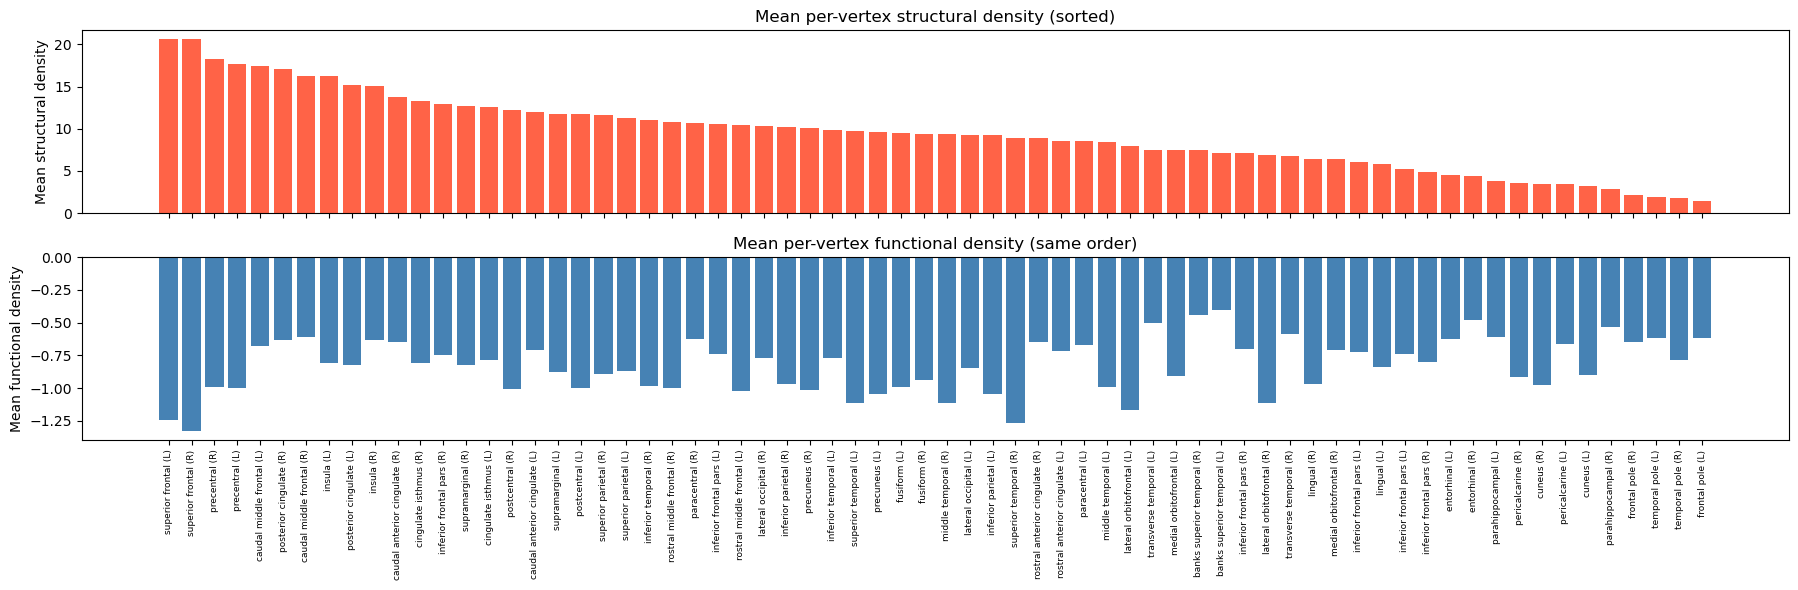

In [7]:
mean_struct = struct_df.mean(axis=0)
mean_func   = func_df.mean(axis=0)

# Sort by structural density for a cleaner plot
sort_idx = mean_struct.argsort()[::-1]
sorted_labels  = [short_label(regions[i]) for i in sort_idx]
sorted_struct  = mean_struct.values[sort_idx]
sorted_func    = mean_func.values[sort_idx]

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

axes[0].bar(range(n_regions), sorted_struct, color="tomato", edgecolor="none")
axes[0].set_ylabel("Mean structural density")
axes[0].set_title("Mean per-vertex structural density (sorted)")

axes[1].bar(range(n_regions), sorted_func, color="steelblue", edgecolor="none")
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set_ylabel("Mean functional density")
axes[1].set_title("Mean per-vertex functional density (same order)")
axes[1].set_xticks(range(n_regions))
axes[1].set_xticklabels(sorted_labels, rotation=90, fontsize=6.5)

plt.tight_layout()
plt.savefig(str(figure_dir / 'mean_density_profiles.png'), dpi=180, bbox_inches="tight")
plt.show()

In [8]:
display_df = results_df.copy()
display_df["short_name"] = display_df["region"].apply(short_label)
display_df = display_df[["short_name", "beta", "r2", "pval", "significant"]].rename(columns={
    "short_name": "Region",
    "beta": "β",
    "r2": "R²",
    "pval": "p-value",
    "significant": "Sig. (Bonf.)"
})
display_df[["β", "R²", "p-value"]] = display_df[["β", "R²", "p-value"]].round(4)
print(display_df.to_string(index=False))

                        Region       β     R²  p-value  Sig. (Bonf.)
          superior frontal (L) -0.0608 0.2907   0.0172         False
     inferior frontal pars (L)  0.0865 0.2574   0.0266         False
         superior parietal (R) -0.0493 0.2199   0.0428         False
           parahippocampal (L) -0.0570 0.2082   0.0496         False
    rostral middle frontal (R) -0.0429 0.1969   0.0571         False
           middle temporal (L)  0.0562 0.1871   0.0644         False
           middle temporal (R)  0.0624 0.1671   0.0822         False
              frontal pole (L)  0.1297 0.1566   0.0935         False
         superior parietal (L) -0.0390 0.1539   0.0966         False
         inferior parietal (L) -0.0445 0.1370   0.1188         False
             pericalcarine (R) -0.0740 0.1344   0.1226         False
                   lingual (L) -0.0913 0.1187   0.1486         False
     inferior frontal pars (L)  0.0291 0.1010   0.1848         False
                entorhinal (R) -0.

**Table 4:** Top 8 vertices by $R^2$ (per-vertex Ordinary Least Squares (OLS): functional density $\sim$ structural density across 19 subjects). None survive Bonferroni correction ($\alpha=0.05/68\approx 0.00074$).

| Region | $\beta$ | $R^2$ | p-value | Bonferroni sig. |
| --- | --- | --- | --- | --- |
| Superior frontal (L) | −0.061 | 0.291 | 0.017 | No |
| Inferior frontal pars triangularis (L) | +0.087 | 0.257 | 0.027 | No |
| Superior parietal (R) | −0.049 | 0.220 | 0.043 | No |
| Parahippocampal (L) | −0.057 | 0.208 | 0.050 | No |
| Rostral middle frontal (R) | −0.043 | 0.197 | 0.057 | No |
| Middle temporal (L) | +0.056 | 0.187 | 0.064 | No |
| Middle temporal (R) | +0.062 | 0.167 | 0.082 | No |
| Frontal pole (L) | +0.130 | 0.157 | 0.094 | No |

## Vertex-level Density Modelling

No vertex showed a significant association between structural and functional density after the Bonferroni correction. The best uncorrected p-value was 0.017(superior frontal gyrus L, $R^2=0.291$, $\beta=-0.061$). The median $R^2$ across all 68 regions was approximately 0.026. Slopes ($\beta$) were mixed in sign: 42 regions showed negative associations and 26 positive.